# Document Classification & Invoice Extraction — Pipeline

This notebook walks through the full pipeline:

| Step | Description |
|------|-------------|
| 0 | Environment check |
| 1 | Download data from HuggingFace |
| 2 | Preprocess images → `.npy` arrays |
| 3 | Explore the dataset |
| 4 | Train classical models (SVD+SVM, HOG+SVM, HOG+RF) |
| 5 | Train CNN |
| 6 | Train stacking ensemble |
| 7 | Evaluate all models on the test set |
| 8 | Predict on a single image |
| 9 | Invoice field extraction |

> **Before running:** make sure your virtual environment is active and all dependencies are installed.
> ```bash
> source .venv/bin/activate
> pip install -r requirements.txt
> python -m spacy download en_core_web_sm
> brew install tesseract  # macOS
> ```

## 0 — Environment check

In [29]:
import importlib, subprocess, sys
from pathlib import Path

ROOT = Path(".").resolve()
print(f"Project root : {ROOT}")
print(f"Python       : {sys.version}")

required = [
    "numpy", "PIL", "sklearn", "skimage",
    "torch", "torchvision",
    "datasets", "huggingface_hub",
    "pytesseract", "cv2", "spacy",
    "flask", "pdfplumber", "joblib",
    "matplotlib", "seaborn",
]

missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  ✗ {pkg}  ← MISSING")
        missing.append(pkg)

if missing:
    print(f"\nMissing packages: {missing}")
    print("Run:  pip install -r requirements.txt")
else:
    print("\nAll packages present.")

# Tesseract binary
try:
    import pytesseract
    ver = pytesseract.get_tesseract_version()
    print(f"\nTesseract version: {ver}")
except Exception as e:
    print(f"\nTesseract not found: {e}")
    print("  macOS:  brew install tesseract")
    print("  Ubuntu: sudo apt-get install tesseract-ocr")

Project root : /Users/oliverholmes/Documents/BCSAI/ThirdYear/Statistical Learning/invoice_classification
Python       : 3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]
  ✓ numpy
  ✓ PIL
  ✓ sklearn
  ✓ skimage
  ✓ torch
  ✓ torchvision
  ✓ datasets
  ✓ huggingface_hub
  ✓ pytesseract
  ✓ cv2


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# Install all dependencies into the active kernel (run once)
%pip install -r requirements.txt -q
%pip install jupyter ipykernel -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1 — Download data

Streams parquet shards from HuggingFace and saves PNG images to `data/raw/`.  
**Targets:** 2 000 train · 500 val · 500 test images per class (4 classes = 12 000 total).  
Progress is checkpointed — safe to interrupt and re-run.

In [ ]:
# Check what's already downloaded
from pathlib import Path

RAW_DIR = ROOT / "data" / "raw"
LABEL_NAMES = ["email", "invoice", "letter", "scientific_report"]
SPLITS = ["train", "validation", "test"]

print("Current download status:")
for split in SPLITS:
    for label in LABEL_NAMES:
        d = RAW_DIR / split / label
        count = len(list(d.glob("*.png"))) if d.exists() else 0
        status = "✓" if count > 0 else "—"
        print(f"  {status} {split:12s}/{label:20s}: {count} images")

Current download status:
  — train       /email               : 0 images
  — train       /invoice             : 0 images
  — train       /letter              : 0 images
  — train       /scientific_report   : 0 images
  — validation  /email               : 0 images
  — validation  /invoice             : 0 images
  — validation  /letter              : 0 images
  — validation  /scientific_report   : 0 images
  — test        /email               : 0 images
  — test        /invoice             : 0 images
  — test        /letter              : 0 images
  — test        /scientific_report   : 0 images


In [ ]:
# Run the downloader (this can take 10-20 minutes on first run)
%run scripts/download_data.py

=== RVL-CDIP image downloader (parquet shard mode) ===
Repo    : chainyo/rvl-cdip
Classes : ['email', 'invoice', 'letter', 'scientific_report']
Targets : {'train': 2000, 'validation': 500, 'test': 500}

[train] listing shards …
  119 shard files found
    [train/email] shard 13/118 …


data/train-00013-of-00119.parquet:   0%|          | 0.00/236M [00:00<?, ?B/s]

    [train/email] shard 14/118 …


data/train-00014-of-00119.parquet:   0%|          | 0.00/216M [00:00<?, ?B/s]

      → 370/2000 saved
    [train/email] shard 15/118 …


...

      → 500/500 saved
    test/letter: 500/500 ✓
    [test/scientific_report] shard 12/14 …


data/test-00012-of-00015.parquet:   0%|          | 0.00/474M [00:00<?, ?B/s]

    [test/scientific_report] shard 13/14 …


data/test-00013-of-00015.parquet:   0%|          | 0.00/293M [00:00<?, ?B/s]

      → 500/500 saved
    test/scientific_report: 500/500 ✓

Done. Images saved to data/raw/
Next step: python scripts/preprocess.py


## 2 — Preprocess

Resizes every image to 128×128 grayscale and serialises to `.npy` arrays for fast loading during training.

In [ ]:
%run scripts/preprocess.py

=== Preprocessing images (size=128×128) ===

[train]
  train/email: 2000 images
  train/invoice: 2000 images
  train/letter: 2000 images
  train/scientific_report: 2000 images
  → 8000 images, labels distribution: [2000 2000 2000 2000]
  Saved to data/processed/train_images.npy

[validation]
  validation/email: 500 images
  validation/invoice: 500 images
  validation/letter: 500 images
  validation/scientific_report: 500 images
  → 2000 images, labels distribution: [500 500 500 500]
  Saved to data/processed/validation_images.npy

[test]
  test/email: 500 images
  test/invoice: 500 images
  test/letter: 500 images
  test/scientific_report: 500 images
  → 2000 images, labels distribution: [500 500 500 500]
  Saved to data/processed/test_images.npy

Done. Next step: python scripts/train_classical.py


In [ ]:
# Verify the output files
import numpy as np

PROC_DIR = ROOT / "data" / "processed"
for split in SPLITS:
    imgs = np.load(PROC_DIR / f"{split}_images.npy")
    lbls = np.load(PROC_DIR / f"{split}_labels.npy")
    print(f"{split:12s}  images: {imgs.shape}  labels: {lbls.shape}  dtype: {imgs.dtype}")

train         images: (8000, 128, 128)  labels: (8000,)  dtype: uint8
validation    images: (2000, 128, 128)  labels: (2000,)  dtype: uint8
test          images: (2000, 128, 128)  labels: (2000,)  dtype: uint8


## 3 — Explore the dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json

PROC_DIR = ROOT / "data" / "processed"

X_train = np.load(PROC_DIR / "train_images.npy")
y_train = np.load(PROC_DIR / "train_labels.npy")

with open(PROC_DIR / "label_map.json") as f:
    label_map = {int(k): v for k, v in json.load(f).items()}

print(f"Training set: {X_train.shape[0]} images, {X_train.shape[1]}×{X_train.shape[2]} px")
print("Class distribution:", {label_map[i]: int(n) for i, n in enumerate(np.bincount(y_train))})

Training set: 8000 images, 128×128 px
Class distribution: {'email': 2000, 'invoice': 2000, 'letter': 2000, 'scientific_report': 2000}


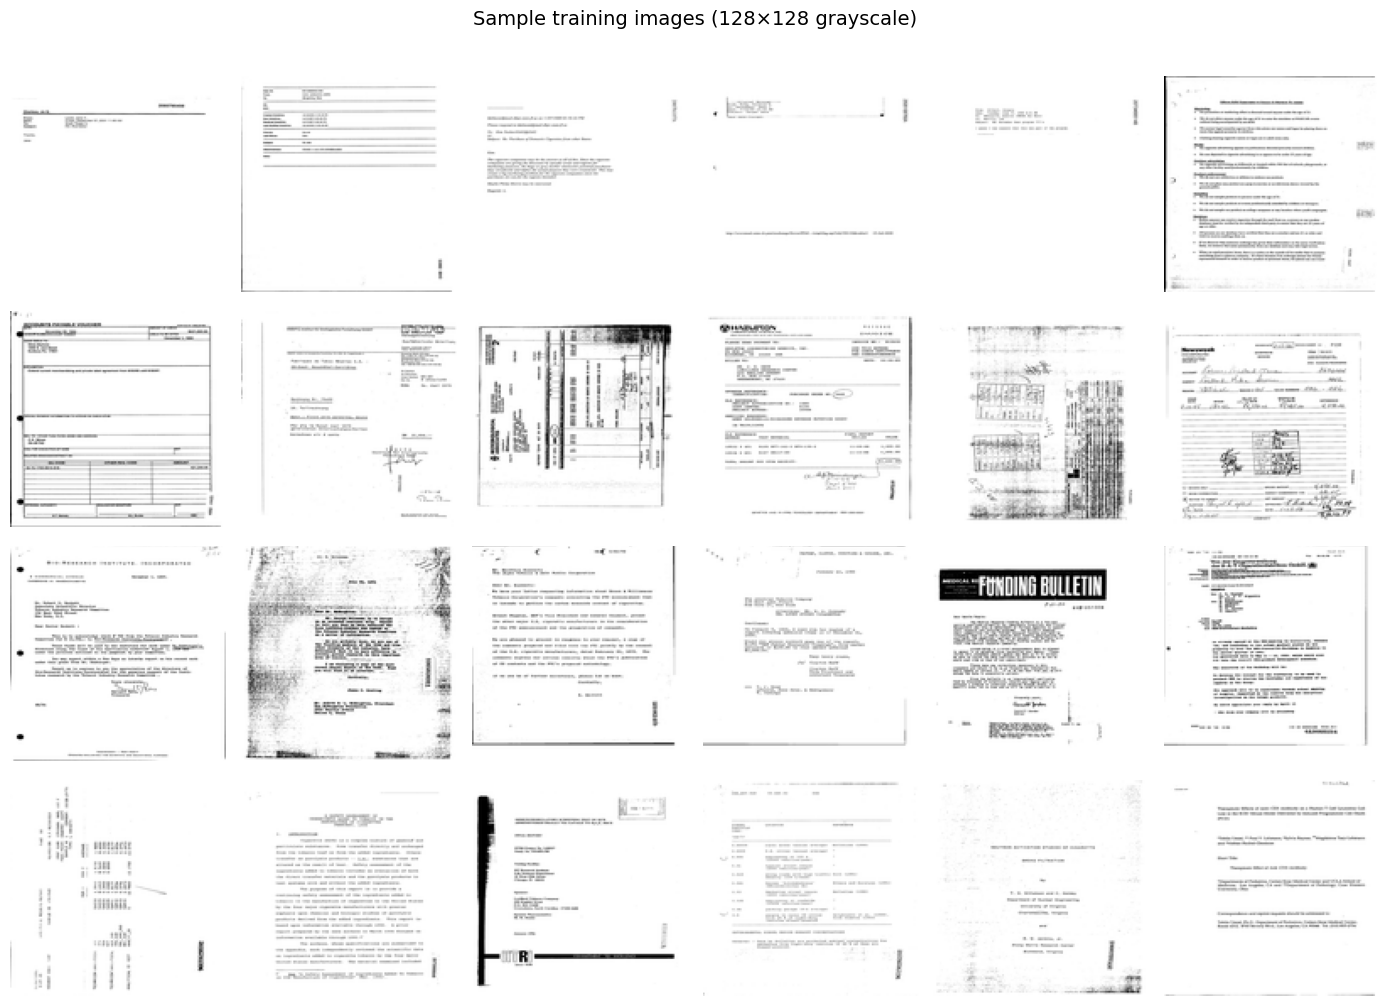

In [ ]:
# Show sample images from each class
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.suptitle("Sample training images (128×128 grayscale)", fontsize=14, y=1.01)

for row, (class_idx, class_name) in enumerate(label_map.items()):
    indices = np.where(y_train == class_idx)[0][:6]
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(X_train[idx], cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(class_name, fontsize=10, rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.show()

/var/folders/_m/kfvhsj6515q3c7pdw8kq_qwc0000gn/T/ipykernel_70557/27161498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[label_map[i] for i in range(len(counts))], y=counts, ax=ax, palette="Blues_d")
/var/folders/_m/kfvhsj6515q3c7pdw8kq_qwc0000gn/T/ipykernel_70557/27161498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[label_map[i] for i in range(len(counts))], y=counts, ax=ax, palette="Blues_d")
/var/folders/_m/kfvhsj6515q3c7pdw8kq_qwc0000gn/T/ipykernel_70557/27161498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[la

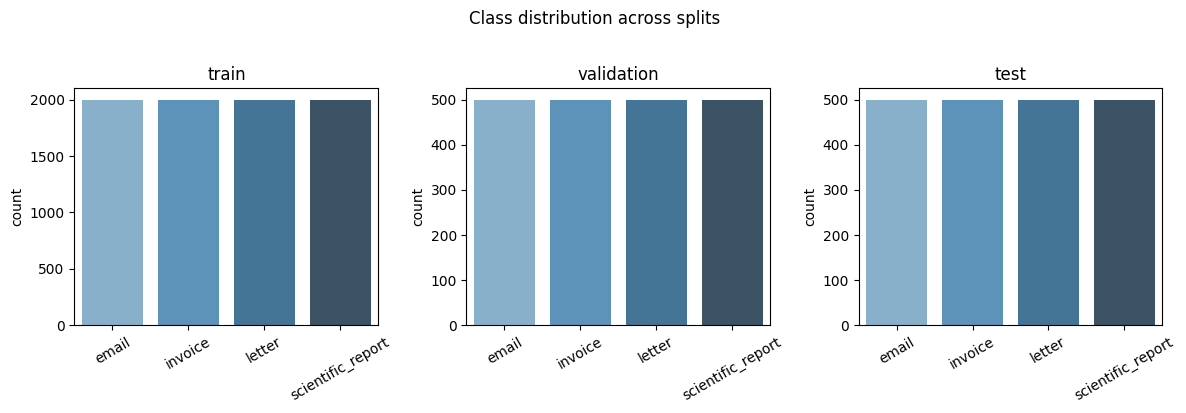

In [ ]:
# Class balance bar chart
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, split in zip(axes, SPLITS):
    lbls = np.load(PROC_DIR / f"{split}_labels.npy")
    counts = np.bincount(lbls)
    sns.barplot(x=[label_map[i] for i in range(len(counts))], y=counts, ax=ax, palette="Blues_d")
    ax.set_title(split)
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Class distribution across splits", y=1.02)
plt.tight_layout()
plt.show()

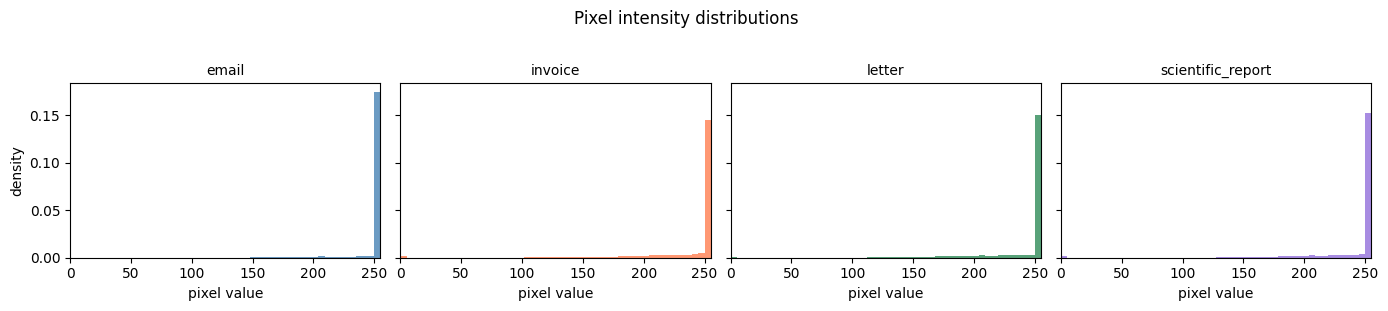

In [ ]:
# Pixel intensity distribution by class
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
colors = ["steelblue", "coral", "seagreen", "mediumpurple"]

for ax, (class_idx, class_name), color in zip(axes, label_map.items(), colors):
    subset = X_train[y_train == class_idx].ravel()
    ax.hist(subset, bins=50, color=color, alpha=0.8, density=True)
    ax.set_title(class_name, fontsize=10)
    ax.set_xlabel("pixel value")
    ax.set_xlim(0, 255)

axes[0].set_ylabel("density")
plt.suptitle("Pixel intensity distributions", y=1.02)
plt.tight_layout()
plt.show()

## 4 — Train classical models

Three scikit-learn pipelines:

- **Model A** — `TruncatedSVD(200)` on raw pixels → `SVC(rbf)`
- **Model B1** — HOG features → `SVC(linear)`
- **Model B2** — HOG features → `RandomForestClassifier(200 trees)`

Takes ~5-10 minutes total.

In [ ]:
%run scripts/train_classical.py

Loading preprocessed data …
  train: (8000, 128, 128)  val: (2000, 128, 128)

--- Model A: SVD + SVM ---
  Extracting pixel features …
  Fitting SVD + SVM (this may take a few minutes) …
  Validation accuracy: 0.7930
                   precision    recall  f1-score   support

            email       0.93      0.92      0.93       500
          invoice       0.70      0.74      0.72       500
           letter       0.79      0.78      0.79       500
scientific_report       0.75      0.73      0.74       500

         accuracy                           0.79      2000
        macro avg       0.79      0.79      0.79      2000
     weighted avg       0.79      0.79      0.79      2000

  Saved → /Users/oliverholmes/Documents/BCSAI/ThirdYear/Statistical Learning/invoice_classification/models/svd_svm.pkl

--- Model B1: HOG + SVM ---
  Extracting HOG features …
  Fitting HOG + SVM …
  Validation accuracy: 0.7440
                   precision    recall  f1-score   support

            email   

## 5 — Train CNN

Architecture:
```
Conv(1→32) → BN → ReLU → MaxPool
Conv(32→64) → BN → ReLU → MaxPool
Conv(64→128) → BN → ReLU → MaxPool
Flatten → FC(32768→512) → Dropout(0.5) → FC(512→4)
```
Trained for 20 epochs with cosine LR decay and light augmentation. Best checkpoint saved to `models/cnn_best.pth`.

In [ ]:
%run scripts/train_cnn.py

=== CNN Training  (device=mps, epochs=20, bs=32, lr=0.001) ===

Train: 8000  Val: 2000


/Users/oliverholmes/Documents/BCSAI/ThirdYear/Statistical Learning/invoice_classification/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/20  train loss=1.9979 acc=0.5105  val loss=0.8059 acc=0.6720 ← best
Epoch 02/20  train loss=0.9124 acc=0.6269  val loss=0.7361 acc=0.7250 ← best
Epoch 03/20  train loss=0.8379 acc=0.6615  val loss=0.7159 acc=0.7340 ← best
Epoch 04/20  train loss=0.8053 acc=0.6713  val loss=0.6110 acc=0.7620 ← best
Epoch 05/20  train loss=0.7636 acc=0.6993  val loss=0.6358 acc=0.7595
Epoch 06/20  train loss=0.7391 acc=0.7046  val loss=0.5507 acc=0.7810 ← best
Epoch 07/20  train loss=0.6965 acc=0.7181  val loss=0.9241 acc=0.6545
Epoch 08/20  train loss=0.6766 acc=0.7302  val loss=0.5320 acc=0.8005 ← best
Epoch 09/20  train loss=0.6408 acc=0.7528  val loss=0.5387 acc=0.7990
Epoch 10/20  train loss=0.6220 acc=0.7514  val loss=0.5003 acc=0.8165 ← best
Epoch 11/20  train loss=0.5714 acc=0.7775  val loss=0.4892 acc=0.8160
Epoch 12/20  train loss=0.5631 acc=0.7784  val loss=0.4681 acc=0.8355 ← best
Epoch 13/20  train loss=0.5326 acc=0.7896  val loss=0.4535 acc=0.8465 ← best
Epoch 14/20  train loss=0.5

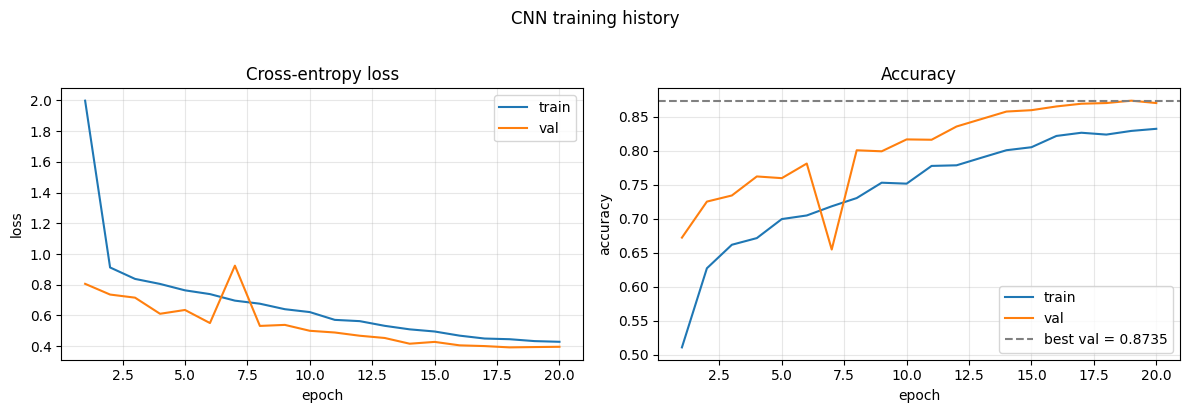

Best val accuracy: 0.8735 (epoch 19)


In [ ]:
# Plot CNN training curves
import json
import matplotlib.pyplot as plt

history_path = ROOT / "reports" / "cnn_training.json"
if not history_path.exists():
    print("Training history not found — run the CNN training cell first.")
else:
    with open(history_path) as f:
        history = json.load(f)

    epochs     = [h["epoch"]      for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss   = [h["val_loss"]   for h in history]
    train_acc  = [h["train_acc"]  for h in history]
    val_acc    = [h["val_acc"]    for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_loss, label="train")
    ax1.plot(epochs, val_loss,   label="val")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.set_title("Cross-entropy loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, train_acc, label="train")
    ax2.plot(epochs, val_acc,   label="val")
    ax2.axhline(max(val_acc), color="gray", linestyle="--",
                label=f"best val = {max(val_acc):.4f}")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("CNN training history", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Best val accuracy: {max(val_acc):.4f} (epoch {val_acc.index(max(val_acc)) + 1})")

## 6 — Train stacking ensemble

Combines the four base models using a **LogisticRegression meta-classifier** trained on the validation set.  
Each base model contributes 4 class probabilities → 16-dimensional meta-feature vector.

In [ ]:
%run scripts/train_stacking.py

Loading base models …

Building meta-features on validation set …
  SVD+SVM scores …
  HOG+SVM scores …
  HOG+RF probabilities …
  CNN probabilities …
  Meta-feature matrix: (2000, 16)

Training meta-classifier (LogisticRegression) …


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

## 7 — Evaluate all models on the test set

Generates confusion matrix plots for every model and saves `reports/results.json`.

In [ ]:
%run scripts/evaluate.py

Loading test data …
  2000 test images

Evaluating SVD + SVM …

  SVD+SVM   (test accuracy: 0.7930)
                   precision    recall  f1-score   support

            email       0.94      0.91      0.92       500
          invoice       0.70      0.79      0.74       500
           letter       0.81      0.74      0.77       500
scientific_report       0.75      0.74      0.74       500

         accuracy                           0.79      2000
        macro avg       0.80      0.79      0.79      2000
     weighted avg       0.80      0.79      0.79      2000

  Confusion matrix → /Users/oliverholmes/Documents/BCSAI/ThirdYear/Statistical Learning/invoice_classification/reports/cm_svd_svm.png

Evaluating HOG + SVM …

  HOG+SVM   (test accuracy: 0.7510)
                   precision    recall  f1-score   support

            email       0.90      0.93      0.92       500
          invoice       0.66      0.72      0.69       500
           letter       0.77      0.72      0.74    

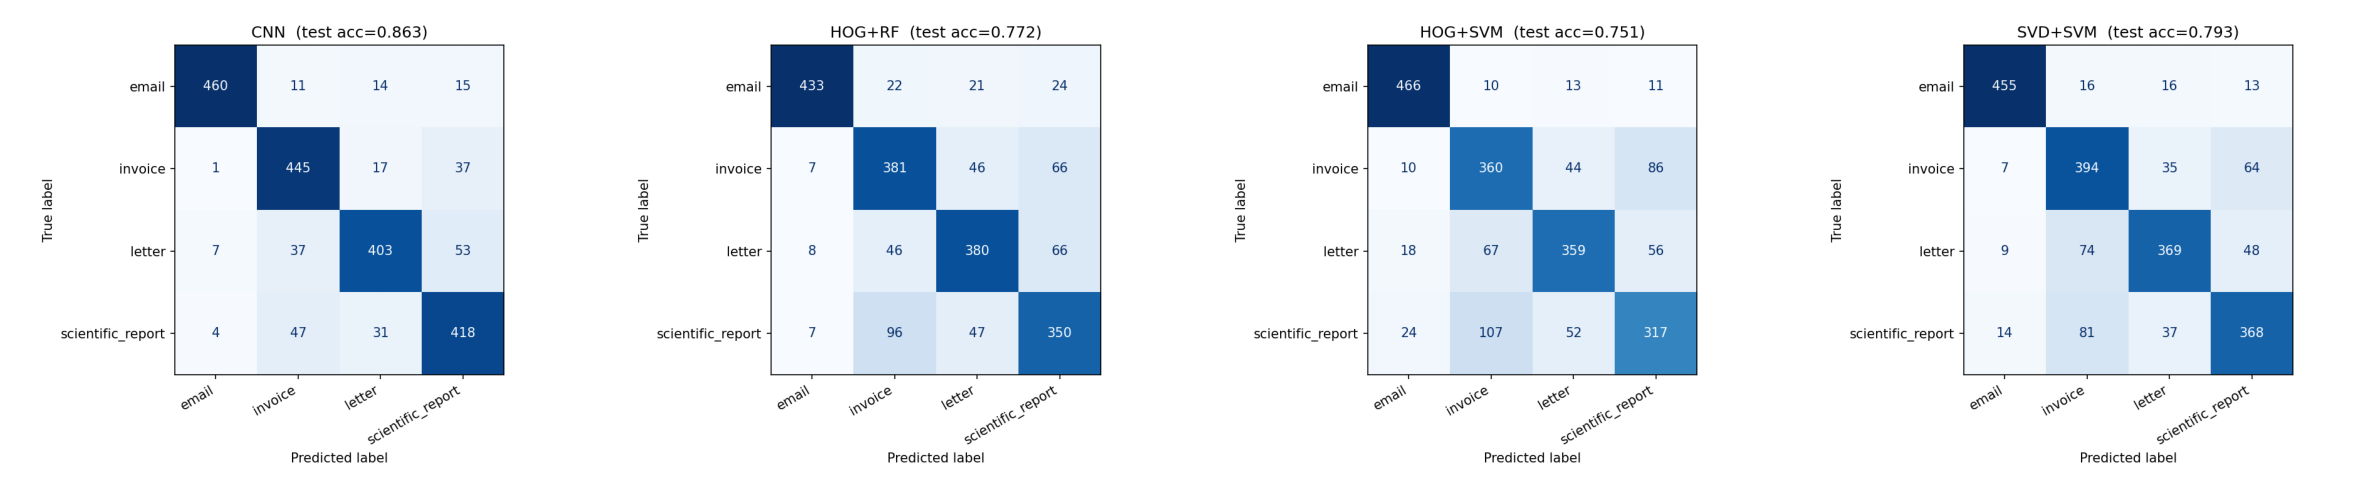

In [ ]:
# Show saved confusion matrix plots
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

REPORTS_DIR = ROOT / "reports"
cm_files = sorted(REPORTS_DIR.glob("cm_*.png"))

if not cm_files:
    print("No confusion matrix plots found. Run the evaluation cell first.")
else:
    n = len(cm_files)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, cm_path in zip(axes, cm_files):
        ax.imshow(mpimg.imread(cm_path))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

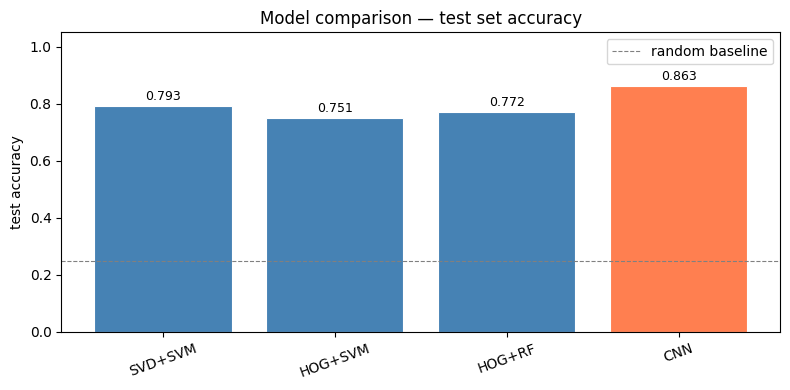

Best model: CNN  (0.8630)


In [ ]:
# Summary bar chart of test accuracies
import json
import matplotlib.pyplot as plt

results_path = ROOT / "reports" / "results.json"
if not results_path.exists():
    print("results.json not found. Run the evaluation cell first.")
else:
    with open(results_path) as f:
        results = json.load(f)

    models = list(results.keys())
    accs   = [results[m] for m in models]
    colors = ["steelblue"] * len(models)
    best_idx = accs.index(max(accs))
    colors[best_idx] = "coral"

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(models, accs, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_ylabel("test accuracy")
    ax.set_title("Model comparison — test set accuracy")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="random baseline")
    ax.legend()
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
                f"{acc:.3f}", ha="center", va="bottom", fontsize=9)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    best_model = models[best_idx]
    print(f"Best model: {best_model}  ({max(accs):.4f})")

## 8 — Predict on a single image

Change `IMAGE_PATH` to any document image (`.png`, `.jpg`, or `.pdf`).

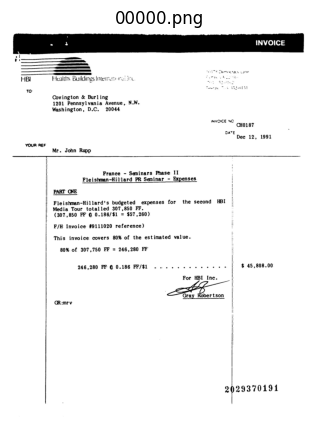

Image shape: (1000, 776)


In [ ]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(ROOT / "scripts"))

# ── Change this to your document ──────────────────────────────────────────────
IMAGE_PATH = ROOT / "data" / "raw" / "test" / "invoice" / "00000.png"
# ──────────────────────────────────────────────────────────────────────────────

if not IMAGE_PATH.exists():
    print(f"Image not found: {IMAGE_PATH}")
    print("Update IMAGE_PATH to a valid file.")
else:
    img = np.array(Image.open(IMAGE_PATH).convert("L"), dtype=np.uint8)

    plt.figure(figsize=(4, 5))
    plt.imshow(img, cmap="gray")
    plt.title(IMAGE_PATH.name)
    plt.axis("off")
    plt.show()

    print(f"Image shape: {img.shape}")

In [ ]:
import joblib, sys, torch
import numpy as np
from torchvision import transforms

sys.path.insert(0, str(ROOT / "scripts"))
MODELS_DIR  = ROOT / "models"
LABEL_NAMES = ["email", "invoice", "letter", "scientific_report"]

stacking_path = MODELS_DIR / "stacking.pkl"

if stacking_path.exists():
    print("Using stacking ensemble …")
    from train_stacking import build_meta_features
    svd_raw     = joblib.load(MODELS_DIR / "svd_svm.pkl")
    hog_svm_raw = joblib.load(MODELS_DIR / "hog_svm.pkl")
    hog_rf_raw  = joblib.load(MODELS_DIR / "hog_rf.pkl")
    meta_clf    = joblib.load(stacking_path)
    svd_svm = svd_raw  if not isinstance(svd_raw,  dict) else svd_raw["pipe"]
    hog_svm = hog_svm_raw["pipe"] if isinstance(hog_svm_raw, dict) else hog_svm_raw
    hog_rf  = hog_rf_raw["pipe"]  if isinstance(hog_rf_raw,  dict) else hog_rf_raw
    M     = build_meta_features(np.array([img]), svd_svm, hog_svm, hog_rf)
    probs = meta_clf.predict_proba(M)[0]
else:
    print("stacking.pkl not found — falling back to CNN …")
    from train_cnn import DocumentCNN
    ckpt  = torch.load(MODELS_DIR / "cnn_best.pth", map_location="cpu")
    model = DocumentCNN(ckpt["num_classes"])
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    tfm = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    with torch.no_grad():
        probs = torch.softmax(model(tfm(img).unsqueeze(0)), dim=1)[0].numpy()

idx   = int(probs.argmax())
label = LABEL_NAMES[idx]
conf  = float(probs[idx])

print(f"\nPredicted class : {label}")
print(f"Confidence      : {conf:.2%}")
print()
print("All class probabilities:")
for name, p in zip(LABEL_NAMES, probs):
    bar = "\u2588" * int(p * 40)
    print(f"  {name:20s} {p:.3f}  {bar}")

stacking.pkl not found — falling back to CNN …

Predicted class : invoice
Confidence      : 99.78%

All class probabilities:
  email                0.000  
  invoice              0.998  ███████████████████████████████████████
  letter               0.002  
  scientific_report    0.000  


## 9 — Invoice field extraction

Only runs on documents classified as `invoice`.  
Uses **Tesseract OCR** for text extraction, then **regex** + **spaCy NER** for structured field parsing.

In [ ]:
from extract import extract_invoice_info

if label != "invoice":
    print(f"Document classified as '{label}', not an invoice — skipping extraction.")
else:
    print("Running invoice extraction …\n")
    fields = extract_invoice_info(img)
    print(json.dumps(fields, indent=2))

Running invoice extraction …

{
  "invoice_number": "9111020",
  "invoice_date": null,
  "due_date": null,
  "issuer_name": null,
  "recipient_name": null,
  "total_amount": "$48,808.00"
}


In [ ]:
# Run extraction on any invoice image by path (regardless of classifier output)
from extract import extract_invoice_from_path

INVOICE_PATH = ROOT / "data" / "raw" / "test" / "invoice" / "00000.png"

if INVOICE_PATH.exists():
    result = extract_invoice_from_path(str(INVOICE_PATH))
    print(json.dumps(result, indent=2))
else:
    print(f"File not found: {INVOICE_PATH}")

{
  "invoice_number": "9111020",
  "invoice_date": null,
  "due_date": null,
  "issuer_name": null,
  "recipient_name": null,
  "total_amount": "$48,808.00"
}
